# Wildfire Detection

## Imports

In [ ]:
!pip install -q torch torchvision pillow -q

In [ ]:
import os
import time
import pickle
import copy
import zipfile
import shutil
from pathlib import Path
from google.colab import drive

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, datasets, models
from torchvision.io import decode_image
from torchvision.models import DenseNet121_Weights
from PIL import Image

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from __future__ import print_function
from __future__ import division

## Loading the Data

Zip files are in the Google Drive. Each file has two folders - wildfire and nowildfire - that contain the images. This section extracts the zip files to the google colab file directory and creates dataset for training, validation, and testing.

Data link: https://www.kaggle.com/datasets/abdelghaniaaba/wildfire-prediction-dataset

In [ ]:
# device configuration - if you want to use gpu
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")

Running on device: cuda:0


In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Configuration
DRIVE_ZIP_FOLDER = '/content/drive/MyDrive/STATS426FINAL'
EXTRACT_BASE_PATH = '/content/data'  # Local extraction path
ZIP_FILES = ['train.zip', 'valid.zip', 'test.zip']  # List your zip files here

os.makedirs(EXTRACT_BASE_PATH, exist_ok=True)

In [ ]:
for zip_file_name in ZIP_FILES:
    zip_path = os.path.join(DRIVE_ZIP_FOLDER, zip_file_name)

    if not os.path.exists(zip_path):
        print(f"Warning: {zip_file_name} not found at {zip_path}")
        continue

    print(f"\nExtracting {zip_file_name}...")

    extract_subfolder = os.path.join(EXTRACT_BASE_PATH, Path(zip_file_name).stem)
    os.makedirs(extract_subfolder, exist_ok=True)

    # Extract zip file
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_subfolder)
        print(f"Successfully extracted {zip_file_name} to {extract_subfolder}")
    except zipfile.BadZipFile:
        print(f"Error: {zip_file_name} is not a valid zip file or is corrupted. Please check its integrity.")
    except OSError as e:
        print(f"OSError during extraction of {zip_file_name}: {e}. This might indicate issues with filenames or metadata within the zip.")
    except Exception as e:
        print(f"An unexpected error occurred while extracting {zip_file_name}: {e}")


Extracting train.zip...
Successfully extracted train.zip to /content/data/train

Extracting valid.zip...
Successfully extracted valid.zip to /content/data/valid

Extracting test.zip...
Successfully extracted test.zip to /content/data/test


## Data Validation

In [ ]:
# running into this error when training:
# RuntimeError: Image is incomplete or truncated
# set up data validation to ensure all images can be decoded
for folder in os.listdir(EXTRACT_BASE_PATH):
  folder_path = os.path.join(EXTRACT_BASE_PATH, folder)
  if folder_path.lower().endswith('.zip'):
    continue
  print('Checking ', folder)
  for img_class in os.listdir(folder_path):
    class_path = os.path.join(folder_path, img_class)
    for img in os.listdir(class_path):
      # make sure that it's an image from the dataset
      if img.lower().endswith(('.jpg', 'jpeg')):
        img_path = os.path.join(class_path, img)
        try:
            image = decode_image(img_path) # func changes images into tensors
            image = image.float() / 255.0
        except Exception as e:
            print(f"Invalid image: {e}, image : {img_path}")

Checking  test
Invalid image: Image is incomplete or truncated, image : /content/data/test/wildfire/-73.15884,46.38819.jpg
Checking  valid
Checking  train
Invalid image: Image is incomplete or truncated, image : /content/data/train/nowildfire/-114.152378,51.027198.jpg


In [ ]:
# proves that the image isn't able to be opened
img = Image.open('/content/data/train/nowildfire/-114.152378,51.027198.jpg')
#img.show()

In [ ]:
# remove the 2 images that are truncated
problem_imgs = ['/content/data/train/nowildfire/-114.152378,51.027198.jpg',
                '/content/data/test/wildfire/-73.15884,46.38819.jpg']
for i in problem_imgs:
  os.remove(i)

In [ ]:
def count_files(folder_type):
  wf = train_count_wf = sum(1 for item in os.listdir(os.path.join(EXTRACT_BASE_PATH, folder_type, 'wildfire')))
  nowf = sum(1 for item in os.listdir(os.path.join(EXTRACT_BASE_PATH, folder_type, 'nowildfire')))
  print(f'Number of {folder_type} images: {wf} wildfire, {nowf} no wildfire')

In [ ]:
# sanity check - make sure expected number of files are present
count_files('train')
count_files('valid')
count_files('test')

Number of train images: 15750 wildfire, 14499 no wildfire
Number of valid images: 3480 wildfire, 2820 no wildfire
Number of test images: 3479 wildfire, 2820 no wildfire


## Create Dataset

In [ ]:
# Custom dataset function for wildfire images from Google Drive zip
class WildfireDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        """
        Args:
            data_dir: Path to folder containing 'wildfire' and 'nowildfire' subfolders
            transform: Optional transform to apply to images
        """
        self.data_dir = data_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        # Class mapping
        class_map = {'wildfire': 1, 'nowildfire': 0}

        # Load image paths and labels
        # both wildfire and nowildfire image paths go into one array
        for class_name, label in class_map.items():
            class_path = os.path.join(data_dir, class_name)

            if os.path.exists(class_path):
                for img_name in os.listdir(class_path):
                    if img_name.lower().endswith(('.jpg', 'jpeg')):
                        self.image_paths.append(os.path.join(class_path, img_name))
                        self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    # pulls actual image from class attribute image paths
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = decode_image(img_path) # func changes images into tensors
        label = self.labels[idx]

        # data augmentations here if necessary
        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
# use custom dataset defined above to create train, valid, test
# densenet needs input tensors to be floats
transform = transforms.Compose([
    transforms.ConvertImageDtype(torch.float32)  # Converts and scales to [0, 1]
])

train_dataset = WildfireDataset(os.path.join(EXTRACT_BASE_PATH, 'train'), transform)
val_dataset = WildfireDataset(os.path.join(EXTRACT_BASE_PATH, 'valid'), transform)
test_dataset = WildfireDataset(os.path.join(EXTRACT_BASE_PATH, 'test'), transform)

In [ ]:
train_dataset.image_paths[0:5]

['/content/data/train/wildfire/-74.6783,46.3469.jpg',
 '/content/data/train/wildfire/-74.93212,46.45714.jpg',
 '/content/data/train/wildfire/-77.952,53.16337.jpg',
 '/content/data/train/wildfire/-71.53205,48.20714.jpg',
 '/content/data/train/wildfire/-73.4733,48.0153.jpg']

In [ ]:
train_dataset.labels[0:5]

[1, 1, 1, 1, 1]

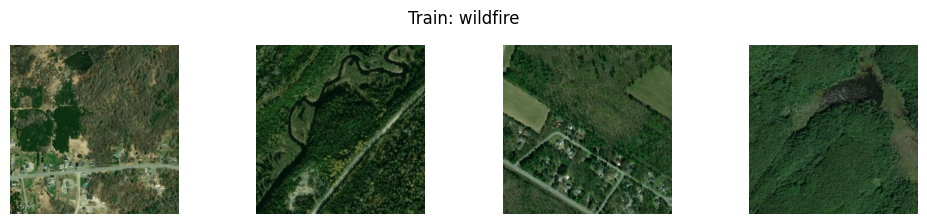

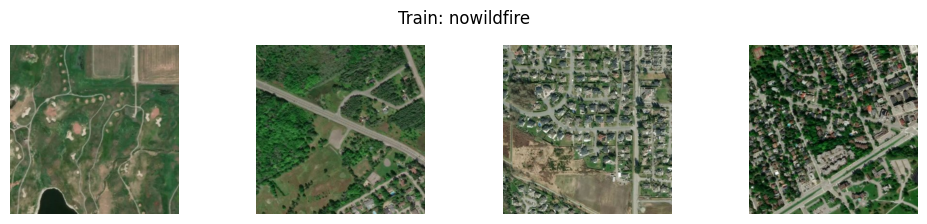

In [ ]:
import random
from PIL import Image
import matplotlib.pyplot as plt

def sample_paths(split_dir, cls, k=12):
    cls_dir = os.path.join(split_dir, cls)
    files = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir) if f.lower().endswith((".jpg",".jpeg",".png"))]
    return random.sample(files, k)

def show_grid(paths, title):
    plt.figure(figsize=(10, 6))
    for i, p in enumerate(paths):
        img = Image.open(p).convert("RGB")
        plt.subplot(3, 4, i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_grid(sample_paths("/content/data/train", "wildfire", 4), "Train: wildfire")
show_grid(sample_paths("/content/data/train", "nowildfire", 4), "Train: nowildfire")

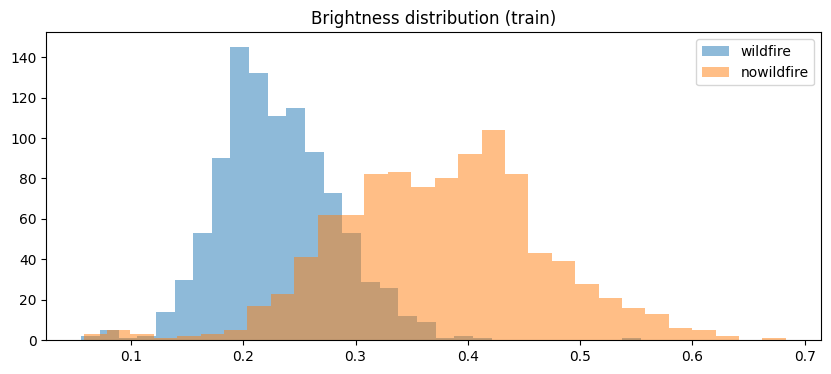

In [ ]:
import numpy as np

def brightness_contrast(split_dir, cls, n=1000):
    cls_dir = os.path.join(split_dir, cls)
    files = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir) if f.lower().endswith((".jpg",".jpeg",".png"))]
    files = random.sample(files, min(n, len(files)))

    b, c = [], []
    for p in files:
        img = Image.open(p).convert("RGB")
        arr = np.asarray(img).astype(np.float32) / 255.0
        gray = arr.mean(axis=2)
        b.append(gray.mean())
        c.append(gray.std())
    return np.array(b), np.array(c)

bw, cw = brightness_contrast("/content/data/train", "wildfire")
bn, cn = brightness_contrast("/content/data/train", "nowildfire")

plt.figure(figsize=(10,4))
plt.hist(bw, bins=30, alpha=0.5, label="wildfire")
plt.hist(bn, bins=30, alpha=0.5, label="nowildfire")
plt.title("Brightness distribution (train)")
plt.legend()
plt.show()

## Baseline CNN

In [ ]:
from torchvision import transforms

IMG_SIZE = 224
BATCH_SIZE = 64

imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std  = (0.229, 0.224, 0.225)

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader
import os

DATA_ROOT = "/content/data"
train_dir = os.path.join(DATA_ROOT, "train")
val_dir   = os.path.join(DATA_ROOT, "valid")
test_dir  = os.path.join(DATA_ROOT, "test")

train_ds = datasets.ImageFolder(train_dir, transform=train_tf)
val_ds   = datasets.ImageFolder(val_dir,   transform=eval_tf)
test_ds  = datasets.ImageFolder(test_dir,  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("class_to_idx:", train_ds.class_to_idx)
NUM_CLASSES = len(train_ds.classes)

# sanity check
x, y = next(iter(train_loader))
print(x.shape)  # should be [B, 3, 224, 224]

class_to_idx: {'nowildfire': 0, 'wildfire': 1}
torch.Size([64, 3, 224, 224])


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

device = "cuda" if torch.cuda.is_available() else "cpu"
criterion = nn.CrossEntropyLoss()

def run_epoch(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    total_loss, total_correct, total_n = 0.0, 0, 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        if train_mode:
            optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        if train_mode:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(1) == yb).sum().item()
        total_n += xb.size(0)

    return total_loss / total_n, total_correct / total_n


def train_model_timed(model, epochs=10, lr=1e-3, weight_decay=0.0):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "epoch_time_sec": []}

    best_val_acc = -1.0
    best_state = None

    for ep in range(1, epochs + 1):
        t0 = time.time()

        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, optimizer=None)

        dt = time.time() - t0

        hist["train_loss"].append(tr_loss)
        hist["val_loss"].append(va_loss)
        hist["train_acc"].append(tr_acc)
        hist["val_acc"].append(va_acc)
        hist["epoch_time_sec"].append(dt)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {ep:02d}/{epochs} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f} | time {dt:.1f}s")

    model.load_state_dict(best_state)
    total_train_time = float(np.sum(hist["epoch_time_sec"]))
    return model, hist, total_train_time


def plot_loss_curves(hist, title):
    epochs = range(1, len(hist["train_loss"]) + 1)
    plt.figure(figsize=(8,5))
    plt.plot(epochs, hist["train_loss"], label="Train Loss")
    plt.plot(epochs, hist["val_loss"], "--", label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-Entropy Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def evaluate_with_time_and_recall(model, loader, class_to_idx, wildfire_name="wildfire"):
    model.eval()
    y_true, y_pred = [], []

    start = time.time()
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            preds = logits.argmax(1).cpu().numpy()
            y_pred.append(preds)
            y_true.append(yb.numpy())
    total_infer_time = time.time() - start

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    cm = confusion_matrix(y_true, y_pred)
    names = list(class_to_idx.keys())
    print("Confusion Matrix:\n", cm)
    print("\nReport:\n", classification_report(y_true, y_pred, target_names=names, digits=4))

    recalls = cm.diagonal() / cm.sum(axis=1)
    recall_dict = {names[i]: float(recalls[i]) for i in range(len(names))}
    print("Recall by class:", recall_dict)

    wildfire_idx = class_to_idx.get(wildfire_name, None)
    if wildfire_idx is not None and wildfire_name in recall_dict:
        print("Wildfire recall:", recall_dict[wildfire_name])

    avg_ms = (total_infer_time / len(y_true)) * 1000.0
    print(f"Inference time (total): {total_infer_time:.2f}s | per image: {avg_ms:.3f} ms")
    return recall_dict, total_infer_time


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
        )
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x).view(x.size(0), -1)
        return self.classifier(x)

In [ ]:
class EnhancedCNN(nn.Module):
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x).view(x.size(0), -1)
        x = self.drop(x)
        return self.fc(x)

BaselineCNN params: 93506
Epoch 01/10 | train loss 0.2478 acc 0.9047 | val loss 0.1689 acc 0.9341 | time 168.6s
Epoch 02/10 | train loss 0.1970 acc 0.9228 | val loss 0.1604 acc 0.9400 | time 166.1s
Epoch 03/10 | train loss 0.1797 acc 0.9311 | val loss 0.1272 acc 0.9524 | time 166.8s
Epoch 04/10 | train loss 0.1594 acc 0.9405 | val loss 0.1204 acc 0.9563 | time 165.7s
Epoch 05/10 | train loss 0.1546 acc 0.9427 | val loss 0.1270 acc 0.9563 | time 165.2s
Epoch 06/10 | train loss 0.1461 acc 0.9467 | val loss 0.1463 acc 0.9435 | time 164.2s
Epoch 07/10 | train loss 0.1387 acc 0.9483 | val loss 0.1329 acc 0.9516 | time 165.3s
Epoch 08/10 | train loss 0.1324 acc 0.9517 | val loss 0.1144 acc 0.9606 | time 166.1s
Epoch 09/10 | train loss 0.1259 acc 0.9537 | val loss 0.1026 acc 0.9648 | time 166.2s
Epoch 10/10 | train loss 0.1216 acc 0.9566 | val loss 0.1060 acc 0.9629 | time 166.7s
BaselineCNN total training time: 1660.9s | avg per epoch: 166.1s


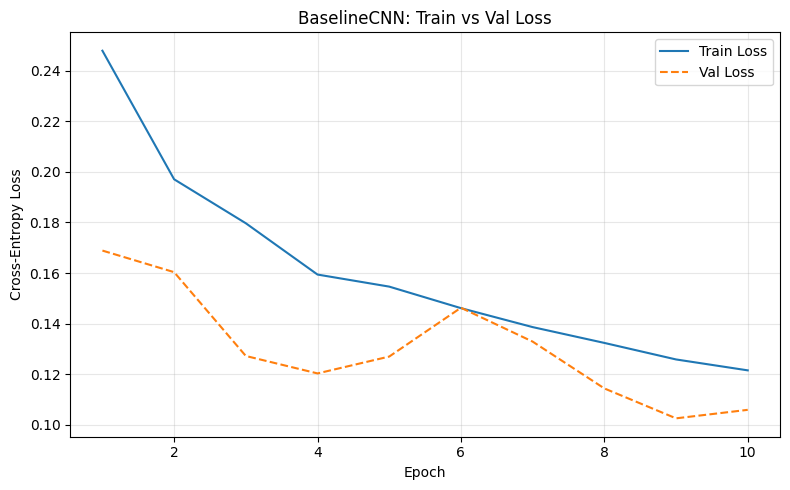


BaselineCNN test evaluation:
Confusion Matrix:
 [[2733   87]
 [  67 3412]]

Report:
               precision    recall  f1-score   support

  nowildfire     0.9761    0.9691    0.9726      2820
    wildfire     0.9751    0.9807    0.9779      3479

    accuracy                         0.9756      6299
   macro avg     0.9756    0.9749    0.9753      6299
weighted avg     0.9756    0.9756    0.9755      6299

Recall by class: {'nowildfire': 0.9691489361702128, 'wildfire': 0.9807415924116125}
Wildfire recall: 0.9807415924116125
Inference time (total): 11.63s | per image: 1.846 ms


In [ ]:
# ---- Train + evaluate BaselineCNN ----
EPOCHS = 10

baseline_cnn = BaselineCNN(num_classes=NUM_CLASSES)
print("BaselineCNN params:", count_params(baseline_cnn))

baseline_cnn, hist_base, train_time_base = train_model_timed(
    baseline_cnn, epochs=EPOCHS, lr=1e-3, weight_decay=0.0
)
print(f"BaselineCNN total training time: {train_time_base:.1f}s | avg per epoch: {train_time_base/EPOCHS:.1f}s")

plot_loss_curves(hist_base, "BaselineCNN: Train vs Val Loss")

print("\nBaselineCNN test evaluation:")
recall_base, infer_time_base = evaluate_with_time_and_recall(
    baseline_cnn, test_loader, train_ds.class_to_idx
)

In [ ]:
# ---- Train + evaluate EnhancedCNN ----
EPOCHS = 10

enhanced_cnn = EnhancedCNN(num_classes=NUM_CLASSES, dropout=0.4)
print("EnhancedCNN params:", count_params(enhanced_cnn))

enhanced_cnn, hist_enh, train_time_enh = train_model_timed(
    enhanced_cnn, epochs=EPOCHS, lr=1e-3, weight_decay=1e-4
)
print(f"EnhancedCNN total training time: {train_time_enh:.1f}s | avg per epoch: {train_time_enh/EPOCHS:.1f}s")

plot_loss_curves(hist_enh, "EnhancedCNN: Train vs Val Loss")

print("\nEnhancedCNN test evaluation:")
recall_enh, infer_time_enh = evaluate_with_time_and_recall(
    enhanced_cnn, test_loader, train_ds.class_to_idx
)